#### Import libraries and load Dataset

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [70]:
housing_df = pd.read_csv('./housing.csv')
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Cleaning and Exploring**

In [71]:
housing_df.shape

(20640, 10)

In [72]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [73]:
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


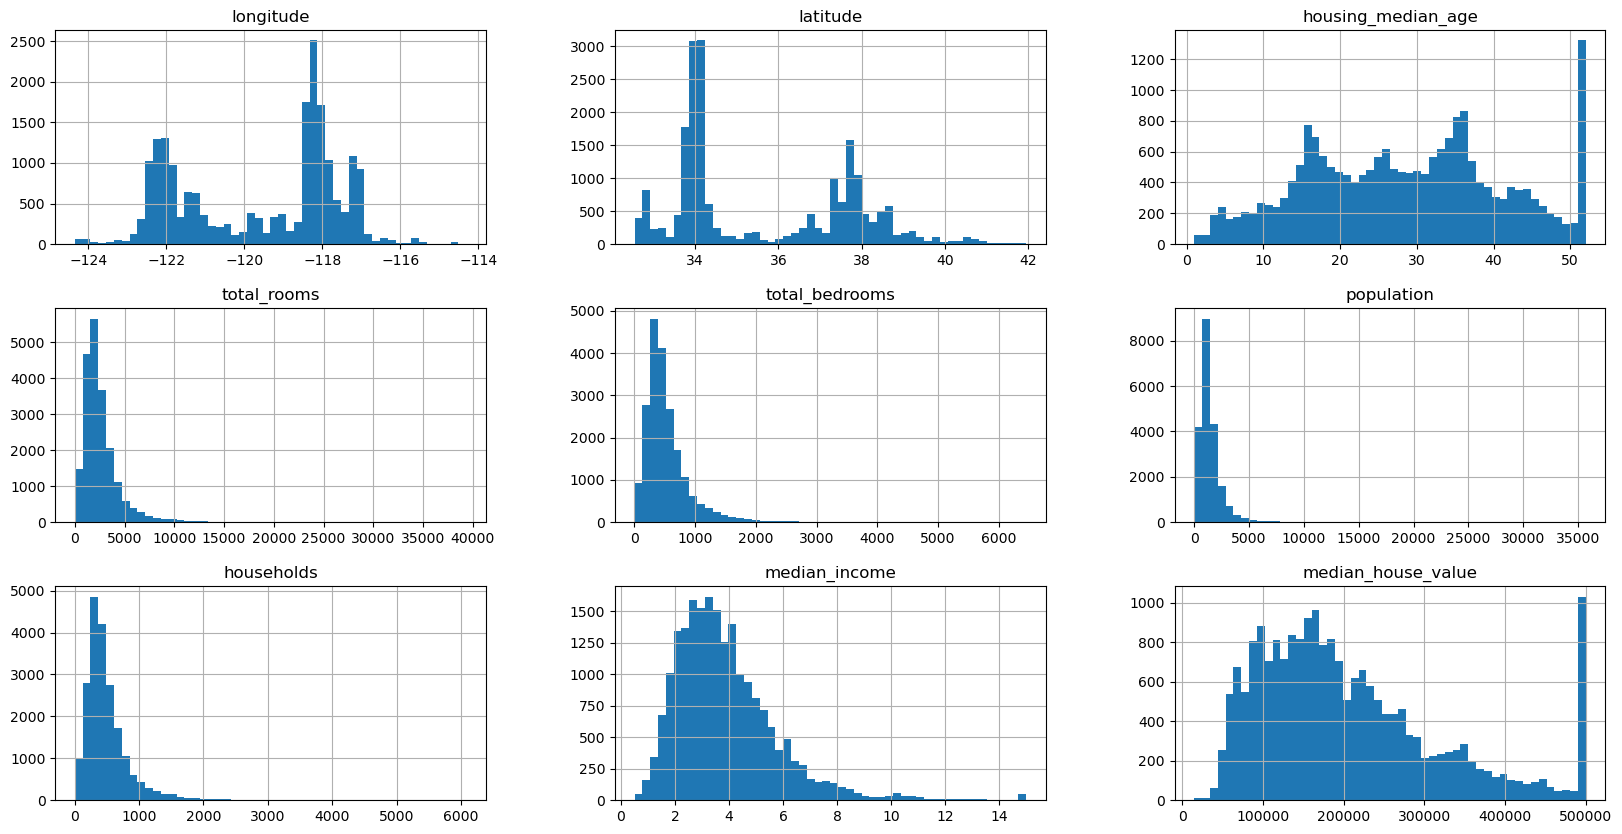

In [74]:
housing_df.hist(bins=50,figsize=(20,10))
plt.show()

Null rows

In [75]:
housing_df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [76]:
housing_df = housing_df.dropna()

In [77]:
housing_df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [78]:
housing_df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

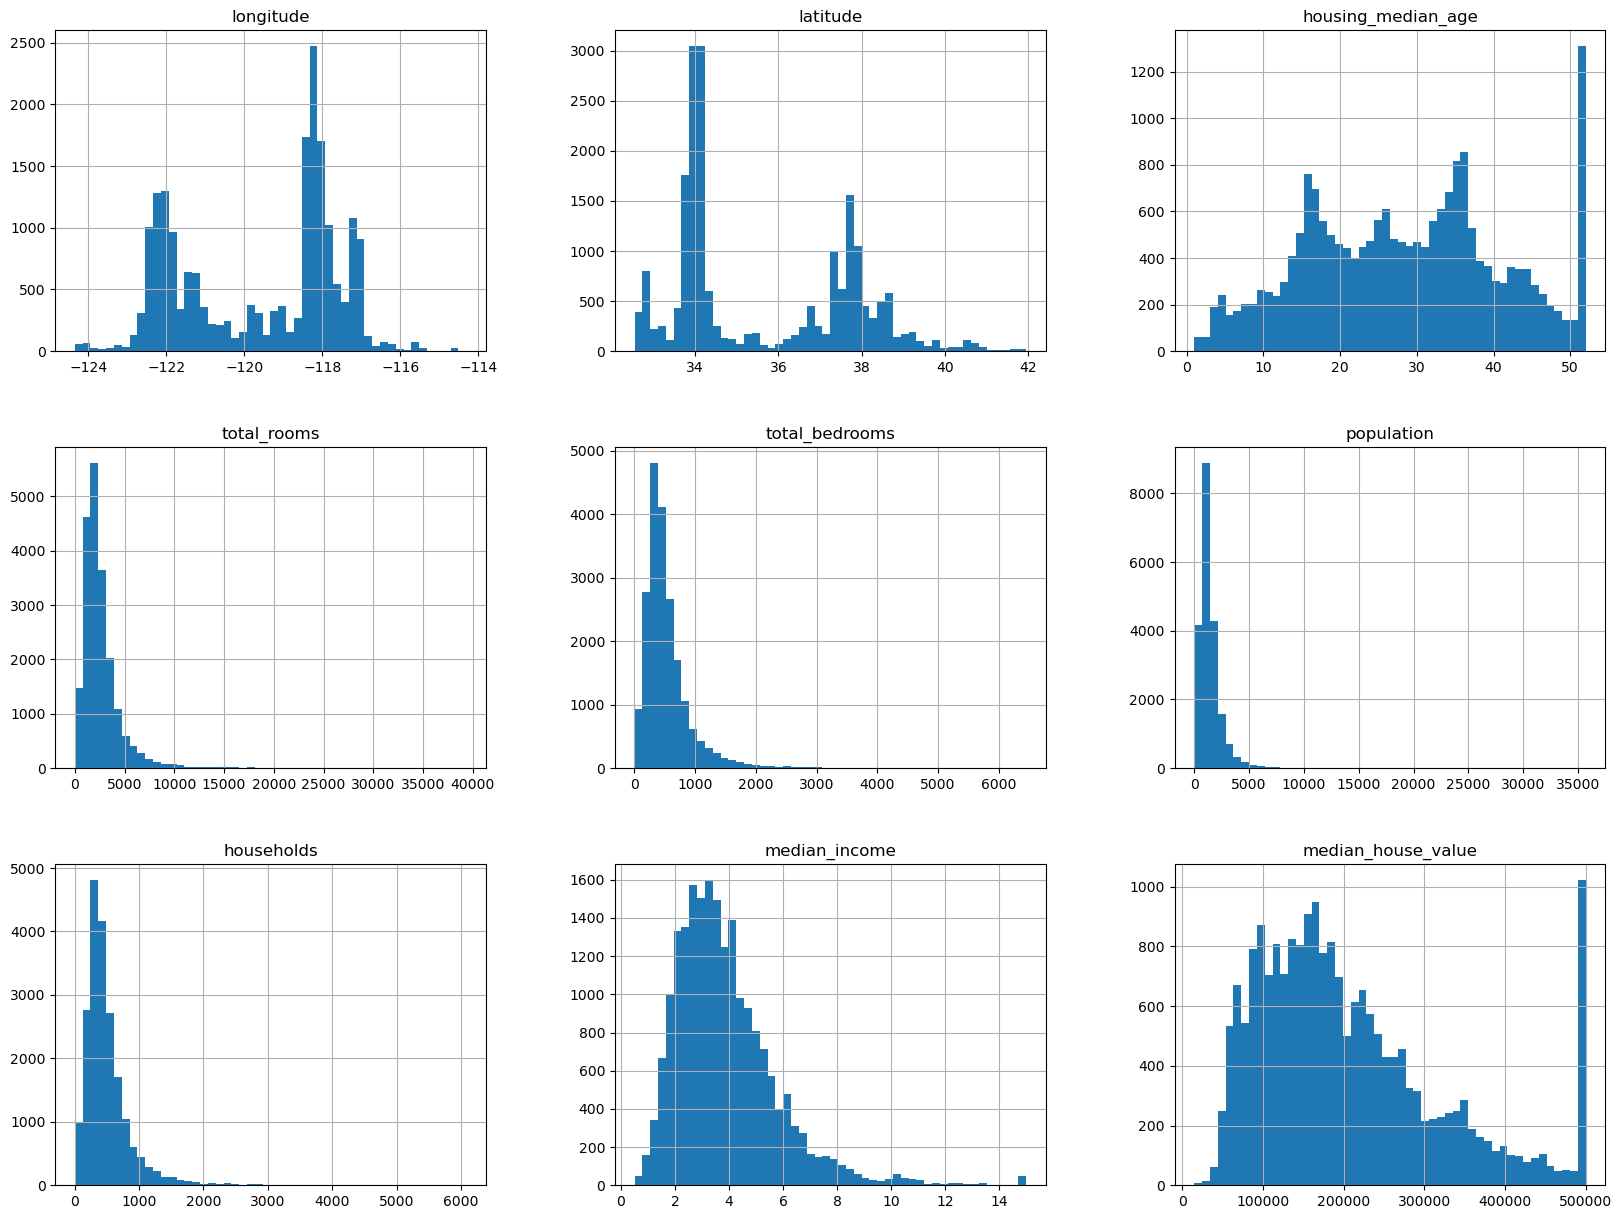

In [79]:
housing_df.hist(bins=50,figsize=(20,15))
plt.show()

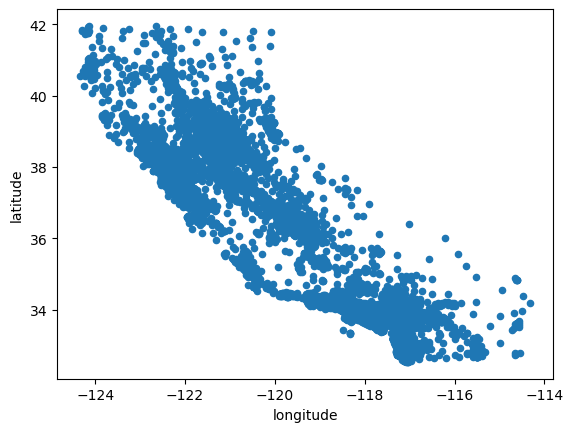

In [80]:
housing_df.plot(kind='scatter',x='longitude',y='latitude')
plt.show()

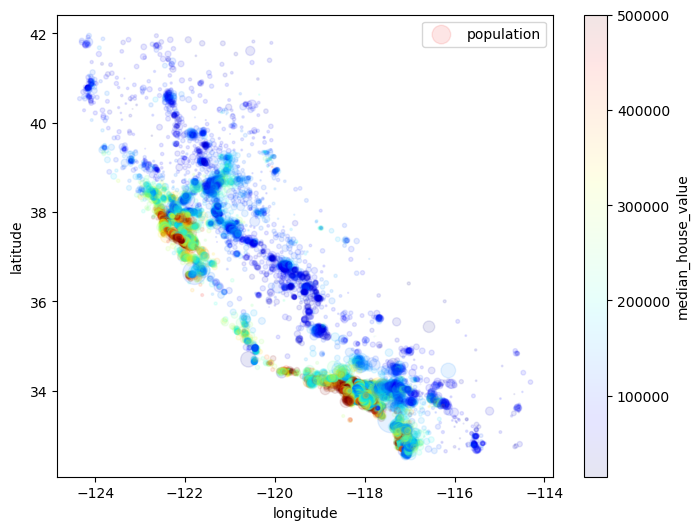

In [81]:
housing_df.plot(kind='scatter',x='longitude',y='latitude',alpha =0.1,s=housing_df['population']/100,label = 'population',
            c='median_house_value',cmap=plt.get_cmap("jet"), figsize=(8,6))
plt.show()


Correlation

In [82]:
#housing_df.corr()

In [83]:
housing_df_shuffled = housing_df.sample(n=len(housing_df),random_state=1)
housing_df_shuffled

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
6715,-118.18,34.14,38.0,3039.0,487.0,1131.0,465.0,7.7116,360900.0,<1H OCEAN
4121,-118.19,34.14,38.0,1826.0,300.0,793.0,297.0,5.2962,291500.0,<1H OCEAN
15433,-117.25,33.20,10.0,2050.0,473.0,1302.0,471.0,2.7961,131300.0,<1H OCEAN
20272,-119.23,34.19,16.0,5297.0,810.0,1489.0,667.0,6.4522,500001.0,NEAR OCEAN
11843,-120.93,39.96,15.0,1666.0,351.0,816.0,316.0,2.9559,118800.0,INLAND
...,...,...,...,...,...,...,...,...,...,...
11065,-117.88,33.79,32.0,1484.0,295.0,928.0,295.0,5.1418,190300.0,<1H OCEAN
17455,-120.43,34.70,26.0,2353.0,389.0,1420.0,389.0,3.8700,125800.0,NEAR OCEAN
5249,-118.45,34.08,52.0,1500.0,176.0,384.0,145.0,7.1576,500001.0,<1H OCEAN
12290,-116.97,33.94,29.0,3197.0,632.0,1722.0,603.0,3.0432,91200.0,INLAND


In [84]:
pd.get_dummies(housing_df_shuffled['ocean_proximity'],dtype=int).head()

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
6715,1,0,0,0,0
4121,1,0,0,0,0
15433,1,0,0,0,0
20272,0,0,0,0,1
11843,0,1,0,0,0


In [85]:
housing_df_final = pd.concat([(housing_df_shuffled.drop('ocean_proximity',axis=1)),
                              (pd.get_dummies(housing_df_shuffled['ocean_proximity'],dtype=int))],axis=1)

housing_df_final

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
6715,-118.18,34.14,38.0,3039.0,487.0,1131.0,465.0,7.7116,360900.0,1,0,0,0,0
4121,-118.19,34.14,38.0,1826.0,300.0,793.0,297.0,5.2962,291500.0,1,0,0,0,0
15433,-117.25,33.20,10.0,2050.0,473.0,1302.0,471.0,2.7961,131300.0,1,0,0,0,0
20272,-119.23,34.19,16.0,5297.0,810.0,1489.0,667.0,6.4522,500001.0,0,0,0,0,1
11843,-120.93,39.96,15.0,1666.0,351.0,816.0,316.0,2.9559,118800.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11065,-117.88,33.79,32.0,1484.0,295.0,928.0,295.0,5.1418,190300.0,1,0,0,0,0
17455,-120.43,34.70,26.0,2353.0,389.0,1420.0,389.0,3.8700,125800.0,0,0,0,0,1
5249,-118.45,34.08,52.0,1500.0,176.0,384.0,145.0,7.1576,500001.0,1,0,0,0,0
12290,-116.97,33.94,29.0,3197.0,632.0,1722.0,603.0,3.0432,91200.0,0,1,0,0,0


In [86]:
corr_matrix = housing_df_final.corr()
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
longitude,1.000000,-0.924616,-0.109357,0.045480,0.069608,0.100270,0.056513,-0.015550,-0.045398,0.320831,-0.055337,0.009501,-0.474714,0.046185
latitude,-0.924616,1.000000,0.011899,-0.036667,-0.066983,-0.108997,-0.071774,-0.079626,-0.144638,-0.446928,0.351084,-0.016662,0.358785,-0.161342
housing_median_age,-0.109357,0.011899,1.000000,-0.360628,-0.320451,-0.295787,-0.302768,-0.118278,0.106432,0.045553,-0.236968,0.017105,0.256149,0.020797
total_rooms,0.045480,-0.036667,-0.360628,1.000000,0.930380,0.857281,0.918992,0.197882,0.133294,-0.003777,0.026477,-0.007603,-0.023647,-0.008674
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,0.018314,-0.006463,-0.004361,-0.019873,0.000679
population,0.100270,-0.108997,-0.295787,0.857281,0.877747,1.000000,0.907186,0.005087,-0.025300,0.073450,-0.019602,-0.010451,-0.061480,-0.023498
households,0.056513,-0.071774,-0.302768,0.918992,0.979728,0.907186,1.000000,0.013434,0.064894,0.041883,-0.038265,-0.009119,-0.011280,0.002106
median_income,-0.015550,-0.079626,-0.118278,0.197882,-0.007723,0.005087,0.013434,1.000000,0.688355,0.168715,-0.237536,-0.009281,0.056677,0.027351
median_house_value,-0.045398,-0.144638,0.106432,0.133294,0.049686,-0.025300,0.064894,0.688355,1.000000,0.257614,-0.484787,0.023525,0.160526,0.140378
<1H OCEAN,0.320831,-0.446928,0.045553,-0.003777,0.018314,0.073450,0.041883,0.168715,0.257614,1.000000,-0.607778,-0.013928,-0.314721,-0.342018


In [87]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688355
<1H OCEAN             0.257614
NEAR BAY              0.160526
NEAR OCEAN            0.140378
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
ISLAND                0.023525
population           -0.025300
longitude            -0.045398
latitude             -0.144638
INLAND               -0.484787
Name: median_house_value, dtype: float64

**Feature Engineering**

In [88]:
housing_df_final['bedrooms_per_room'] = housing_df_final['total_bedrooms'] / housing_df_final['total_rooms']
housing_df_final['population_per_household'] = housing_df_final['population']/ housing_df_final['households']
housing_df_final['rooms_per_household'] = housing_df_final['total_rooms']/housing_df_final['households']

In [89]:
corr_matrix = housing_df_final.corr()
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688355
<1H OCEAN                   0.257614
NEAR BAY                    0.160526
rooms_per_household         0.151344
NEAR OCEAN                  0.140378
total_rooms                 0.133294
housing_median_age          0.106432
households                  0.064894
total_bedrooms              0.049686
ISLAND                      0.023525
population_per_household   -0.023639
population                 -0.025300
longitude                  -0.045398
latitude                   -0.144638
bedrooms_per_room          -0.255880
INLAND                     -0.484787
Name: median_house_value, dtype: float64

**Observation:** The new created feature `bedrooms_per_room` shows the high correralation:
- Houses with less bedroom will tend to be more expensive

In [92]:
help(plt.axis)

Help on function axis in module matplotlib.pyplot:

axis(arg: 'tuple[float, float, float, float] | bool | str | None' = None, /, *, emit: 'bool' = True, **kwargs) -> 'tuple[float, float, float, float]'
    Convenience method to get or set some axis properties.
    
    Call signatures::
    
      xmin, xmax, ymin, ymax = axis()
      xmin, xmax, ymin, ymax = axis([xmin, xmax, ymin, ymax])
      xmin, xmax, ymin, ymax = axis(option)
      xmin, xmax, ymin, ymax = axis(**kwargs)
    
    Parameters
    ----------
    xmin, xmax, ymin, ymax : float, optional
        The axis limits to be set.  This can also be achieved using ::
    
            ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax))
    
    option : bool or str
        If a bool, turns axis lines and labels on or off. If a string,
        possible values are:
    
        ================ ===========================================================
        Value            Description
        ================ ======================

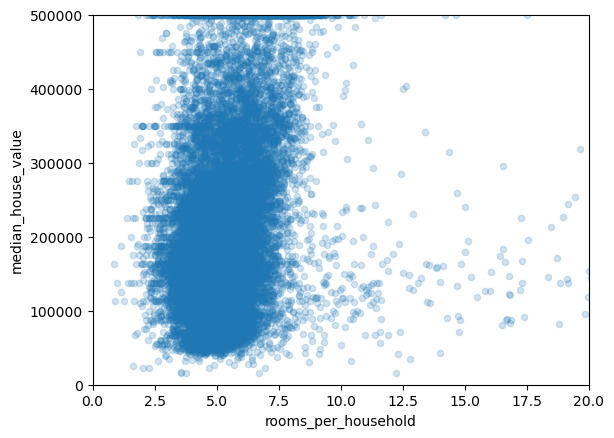

In [95]:
# do scatter for the three created features
housing_df_final.plot(kind='scatter',x='rooms_per_household',y='median_house_value',alpha=0.2)
plt.axis([0,20,0,500000])
plt.show()

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix( )

In [23]:
housing_df_final.columns

NameError: name 'housing_df_final' is not defined

In [15]:
housing_df_final

[['longitude',
  'latitude',
  'housing_median_age',
  'total_rooms',
  'total_bedrooms',
  'population',
  'households',
  'median_income',
  '<1H OCEAN',
  'INLAND',
  'ISLAND',
  'NEAR BAY',
  'NEAR OCEAN',
  'median_house_value']]

In [17]:
housing_df_final = housing_df_final[['longitude', 'latitude', 
                                     'housing_median_age', 'total_rooms',
                                    'total_bedrooms', 'population', 'households', 
                                    'median_income', '<1H OCEAN', 'INLAND', 'ISLAND',
                                    'NEAR BAY','NEAR OCEAN','median_house_value']]

housing_df_final

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,median_house_value
4712,-118.36,34.06,39.0,2810.0,670.0,1109.0,624.0,3.2500,1,0,0,0,0,355000.0
2151,-119.78,36.78,37.0,2185.0,455.0,1143.0,438.0,1.9784,0,1,0,0,0,70700.0
15927,-122.42,37.73,46.0,1819.0,411.0,1534.0,406.0,4.0132,0,0,0,1,0,229400.0
82,-122.28,37.81,52.0,340.0,97.0,200.0,87.0,1.5208,0,0,0,1,0,112500.0
8161,-118.13,33.82,37.0,1530.0,290.0,711.0,283.0,5.1795,1,0,0,0,0,225400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10955,-117.88,33.76,17.0,1768.0,474.0,1079.0,436.0,1.7823,1,0,0,0,0,205300.0
17289,-119.63,34.42,42.0,1765.0,263.0,753.0,260.0,8.5608,1,0,0,0,0,500001.0
5192,-118.26,33.93,42.0,1433.0,295.0,775.0,293.0,1.1326,1,0,0,0,0,104800.0
12172,-117.16,33.73,10.0,2381.0,454.0,1323.0,477.0,2.6322,0,1,0,0,0,140700.0


**Split the dataset into Train, Test, and Validation**

In [22]:
len(housing_df_final)

20433

In [24]:
train_df,test_df,val_df = housing_df_final[:18000],housing_df_final[18000:19217],housing_df_final[19215:]
len(train_df),len(test_df),len(val_df)

(18000, 1217, 1218)

In [25]:
train_df.shape

(18000, 14)

In [29]:
X_train, y_train = train_df.to_numpy()[:,:-1],train_df.to_numpy()[:,-1]
X_val,y_val = val_df.to_numpy()[:,:-1],val_df.to_numpy()[:,-1]
X_test, y_test = test_df.to_numpy()[:,:-1],test_df.to_numpy()[:,-1]

In [31]:
X_train.shape,y_train.shape,X_val.shape,y_val.shape,X_test.shape, y_test.shape

((18000, 13), (18000,), (1218, 13), (1218,), (1217, 13), (1217,))

**Preprocessing**

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
scaler = StandardScaler().fit(X_train[:,:8])

def preprocessor(X):
    A = np.copy(X)
    A[:,:8] = scaler.transform(A[:,:8])
    return A

X_train_preprocessed = preprocessor(X_train)
X_train_preprocessed

array([[ 0.60344338, -0.73607301,  0.82084451, ...,  0.        ,
         0.        ,  0.        ],
       [-0.10512186,  0.53710782,  0.66177382, ...,  0.        ,
         0.        ,  0.        ],
       [-1.42245442,  0.98178495,  1.37759191, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.59346359, -0.7313922 , -0.61079167, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.12738246, -0.7313922 ,  0.90037985, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.92279673, -0.94202873, -0.61079167, ...,  0.        ,
         0.        ,  0.        ]])

In [34]:
pd.DataFrame(X_train_preprocessed)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.603443,-0.736073,0.820845,0.081039,0.315396,-0.276840,0.328234,-0.326667,1.0,0.0,0.0,0.0,0.0
1,-0.105122,0.537108,0.661774,-0.206526,-0.196843,-0.246809,-0.160526,-0.995001,0.0,1.0,0.0,0.0,0.0
2,-1.422454,0.981785,1.377592,-0.374924,-0.301674,0.098553,-0.244613,0.074459,0.0,0.0,0.0,1.0,0.0
3,-1.352596,1.019231,1.854804,-1.055419,-1.049782,-1.079740,-1.082862,-1.235508,0.0,0.0,0.0,1.0,0.0
4,0.718211,-0.848412,0.661774,-0.507894,-0.589957,-0.628385,-0.567825,0.687448,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,0.728191,-0.815647,0.423168,-0.057912,0.134325,0.111802,0.120643,-0.349320,1.0,0.0,0.0,0.0,0.0
17996,-0.459404,0.785191,1.298057,-0.368023,-0.277849,-0.015390,-0.241986,-0.956265,0.0,1.0,0.0,0.0,0.0
17997,0.593464,-0.731392,-0.610792,0.468908,0.996794,0.077354,1.027213,-0.165155,1.0,0.0,0.0,0.0,0.0
17998,1.127382,-0.731392,0.900380,0.139013,0.463112,0.531359,0.464877,-0.923784,0.0,1.0,0.0,0.0,0.0


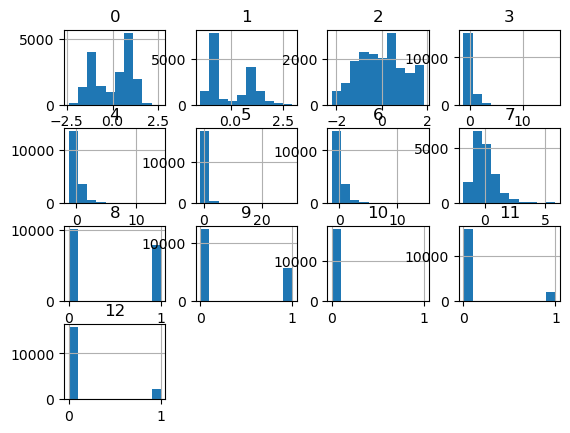

In [38]:

pd.DataFrame(X_train_preprocessed).hist()
plt.show()

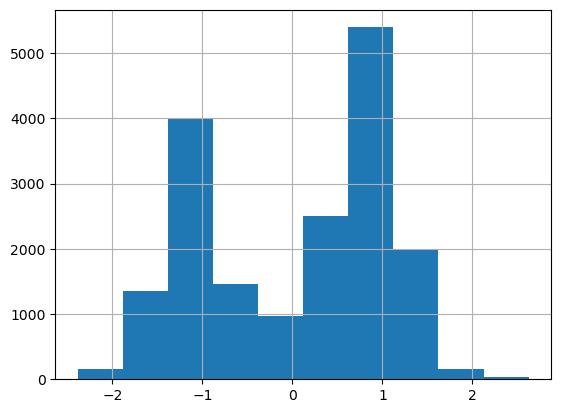

In [40]:
pd.DataFrame(X_train_preprocessed)[0].hist()
plt.show()

In [41]:
X_train,X_val,X_test = preprocessor(X_train),preprocessor(X_val),preprocessor(X_test)

In [42]:
X_train.shape,X_val.shape,X_test.shape

((18000, 13), (1218, 13), (1217, 13))

**Model**

In [43]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

**Linear Model**

In [45]:
lm = LinearRegression()
lm.fit(X_train,y_train)
mse = mean_squared_error(lm.predict(X_train),y_train)
print('Mean Squared error: ',mse)
rmse = mean_squared_error(lm.predict(X_train),y_train,squared=False)
print('Root mean squared error:',rmse)

Mean Squared error:  4705007301.412742
Root mean squared error: 68593.05578127236


In [46]:
lm = LinearRegression()
lm.fit(X_train,y_train)
mse = mean_squared_error(lm.predict(X_val),y_val)
print('Mean Squared error: ',mse)
rmse = mean_squared_error(lm.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)

Mean Squared error:  5095452109.80421
Root mean squared error: 71382.43558330165


**KNeighborsRegressor**

In [47]:
from sklearn.neighbors import KNeighborsRegressor

In [56]:
knn = KNeighborsRegressor(n_neighbors=15)
knn.fit(X_train,y_train)
mse = mean_squared_error(knn.predict(X_train),y_train,squared=False)
print('Root Mean Squared error: ',mse)
rmse = mean_squared_error(knn.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)


Root Mean Squared error:  55797.60309166373
Root mean squared error: 62069.66323809072


**Random forest**

In [50]:
from sklearn.ensemble import RandomForestRegressor


In [59]:
rfr = RandomForestRegressor(max_depth=10)
rfr.fit(X_train,y_train)
mse = mean_squared_error(rfr.predict(X_train),y_train,squared=False)
print('Root Mean Squared error: ',mse)
rmse = mean_squared_error(rfr.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)


Root Mean Squared error:  43425.787902666
Root mean squared error: 53488.09275526526


**Gradient Boosting**

In [60]:
from sklearn.ensemble import GradientBoostingRegressor

In [63]:
gbr = RandomForestRegressor(n_estimators=250)
gbr.fit(X_train,y_train)
mse = mean_squared_error(gbr.predict(X_train),y_train,squared=False)
print('Root Mean Squared error: ',mse)
rmse = mean_squared_error(gbr.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)


Root Mean Squared error:  17817.643350564384
Root mean squared error: 49293.149419632384


**Tensorflow**

In [ ]:
from